# Rapport de Synthèse — RIE BNP Paribas
## Prédiction de la demande de repas : du jeu de données brut au modèle cascade

Ce notebook documente l'intégralité du travail réalisé, du fichier brut `data/raw/real.csv`
jusqu'aux résultats finaux du modèle déployé. Il réutilise les artefacts sauvegardés
(CSV intermédiaires, pickles de modèles) sans réentraîner.

**Pipeline reproduit :** notebooks 01 → 02 → 03 → 04 → 05

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
%matplotlib inline
import seaborn as sns
import joblib
import json
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

ROOT = Path.cwd().parent
print(f"Racine du projet : {ROOT}")

Racine du projet : d:\BNP_RIE_Stage\rie-project-skeleton\rie-project


---
# 1. DONNÉES BRUTES — `data/raw/real.csv`

In [3]:
raw_path = ROOT / 'data' / 'raw' / 'real.csv'
raw = pd.read_csv(raw_path, sep=';', encoding='cp1252')

print(f"Fichier : {raw_path.name}")
print(f"Shape   : {raw.shape[0]} lignes × {raw.shape[1]} colonnes")
print(f"Plaine temporelle : {raw.Date.iloc[0]} → {raw.Date.iloc[-1]}")

Fichier : real.csv
Shape   : 666 lignes × 14 colonnes
Plaine temporelle : 02/01/2022 → 31/12/2024


In [4]:
print("=== Colonnes du fichier brut ===")
for i, (col, dtype) in enumerate(zip(raw.columns, raw.dtypes)):
    print(f"  {i+1:2d}. {col:45s} → {dtype}")

=== Colonnes du fichier brut ===
   1. Date                                          → object
   2. office_presence                               → int64
   3. cantine_presence                              → int64
   4. entrées                                       → object
   5. plat pricipal_1                               → object
   6. plat principal_2                              → object
   7. temperature                                   → float64
   8. temperature ressentie                         → float64
   9. precipitation (mm)                            → float64
  10. type precipitation                            → object
  11. vitesse soulevement du vent (km/h)            → float64
  12. vitesse du vent(km/h)                         → float64
  13. couverture nuageuse (%)                       → float64
  14. conditions                                    → object


In [5]:
print("\n=== Valeurs manquantes ===")
nulls = raw.isna().sum()
print(nulls[nulls > 0].to_string())


=== Valeurs manquantes ===
plat principal_2                      253
temperature                            37
temperature ressentie                  37
precipitation (mm)                     37
type precipitation                     37
vitesse soulevement du vent (km/h)     37
vitesse du vent(km/h)                  37
couverture nuageuse (%)                37
conditions                             37


In [6]:
print("\n=== Valeurs nulles cibles ===")
print(f"office_presence == 0 : {(raw['office_presence'] == 0).sum()} lignes")
print(f"cantine_presence == 0 : {(raw['cantine_presence'] == 0).sum()} lignes")


=== Valeurs nulles cibles ===
office_presence == 0 : 37 lignes
cantine_presence == 0 : 38 lignes


### Problèmes structurels détectés

In [7]:
problems = pd.DataFrame({
    'Problème': [
        'Encodage cp1252 (\'entrées\' corrompu dans le CSV)',
        'Faute de frappe : \'plat pricipal_1\' (plat principal)',
        'plat principal_2 : 253 manquants (38%)',
        'Type precipitation : 37 manquants (6%)',
        'Données météo manquantes (37 lignes, systeme en bascule)',
        '38 lignes avec cantine_presence = 0 (fermeture cantine)',
        '37 lignes avec office_presence = 0 (systeme ferme, jan-mar 2022)',
    ],
    'Gravité': [
        'Haute', 'Moyenne', 'Haute',
        'Haute', 'Haute', 'Haute', 'Haute'
    ]
})
print(problems.to_string(index=False))

                                                        Problème Gravité
                Encodage cp1252 ('entrées' corrompu dans le CSV)   Haute
            Faute de frappe : 'plat pricipal_1' (plat principal) Moyenne
                          plat principal_2 : 253 manquants (38%)   Haute
                          Type precipitation : 37 manquants (6%)   Haute
        Données météo manquantes (37 lignes, systeme en bascule)   Haute
         38 lignes avec cantine_presence = 0 (fermeture cantine)   Haute
37 lignes avec office_presence = 0 (systeme ferme, jan-mar 2022)   Haute


---
# 2. STATS DESCRIPTIVES PAR COLONNE

In [8]:
num_cols_raw = ['office_presence', 'cantine_presence', 'temperature',
                'temperature ressentie', 'precipitation (mm)',
                'vitesse du vent(km/h)', 'couverture nuageuse (%)']

desc_list = []
for col in num_cols_raw:
    s = raw[col]
    desc_list.append({
        'Colonne': col,
        'N': s.count(),
        'Moyenne': round(s.mean(), 2),
        'Médiane': round(s.median(), 2),
        'Écart-type': round(s.std(), 2),
        'Min': round(s.min(), 2),
        'Max': round(s.max(), 2),
        'Skewness': round(s.skew(), 3),
        '% Manquants': round(s.isna().mean() * 100, 1),
    })

desc_num = pd.DataFrame(desc_list)
print("=== Statistiques numériques (données brutes) ===")
print(desc_num.to_string(index=False))

=== Statistiques numériques (données brutes) ===
                Colonne   N  Moyenne  Médiane  Écart-type  Min   Max  Skewness  % Manquants
        office_presence 666   506.12    549.0      144.85  0.0 644.0    -2.664          0.0
       cantine_presence 666   308.67    329.0       87.76  0.0 534.0    -2.451          0.0
            temperature 629    21.00     21.5        5.64  7.6  35.8    -0.185          5.6
  temperature ressentie 629    21.34     21.5        6.22  6.4  37.2    -0.014          5.6
     precipitation (mm) 629     1.11      0.0        3.68  0.0  35.0     5.311          5.6
  vitesse du vent(km/h) 629    18.58     18.0        6.73  5.8  48.6     0.872          5.6
couverture nuageuse (%) 629    35.30     32.6       26.52  0.0  96.6     0.394          5.6


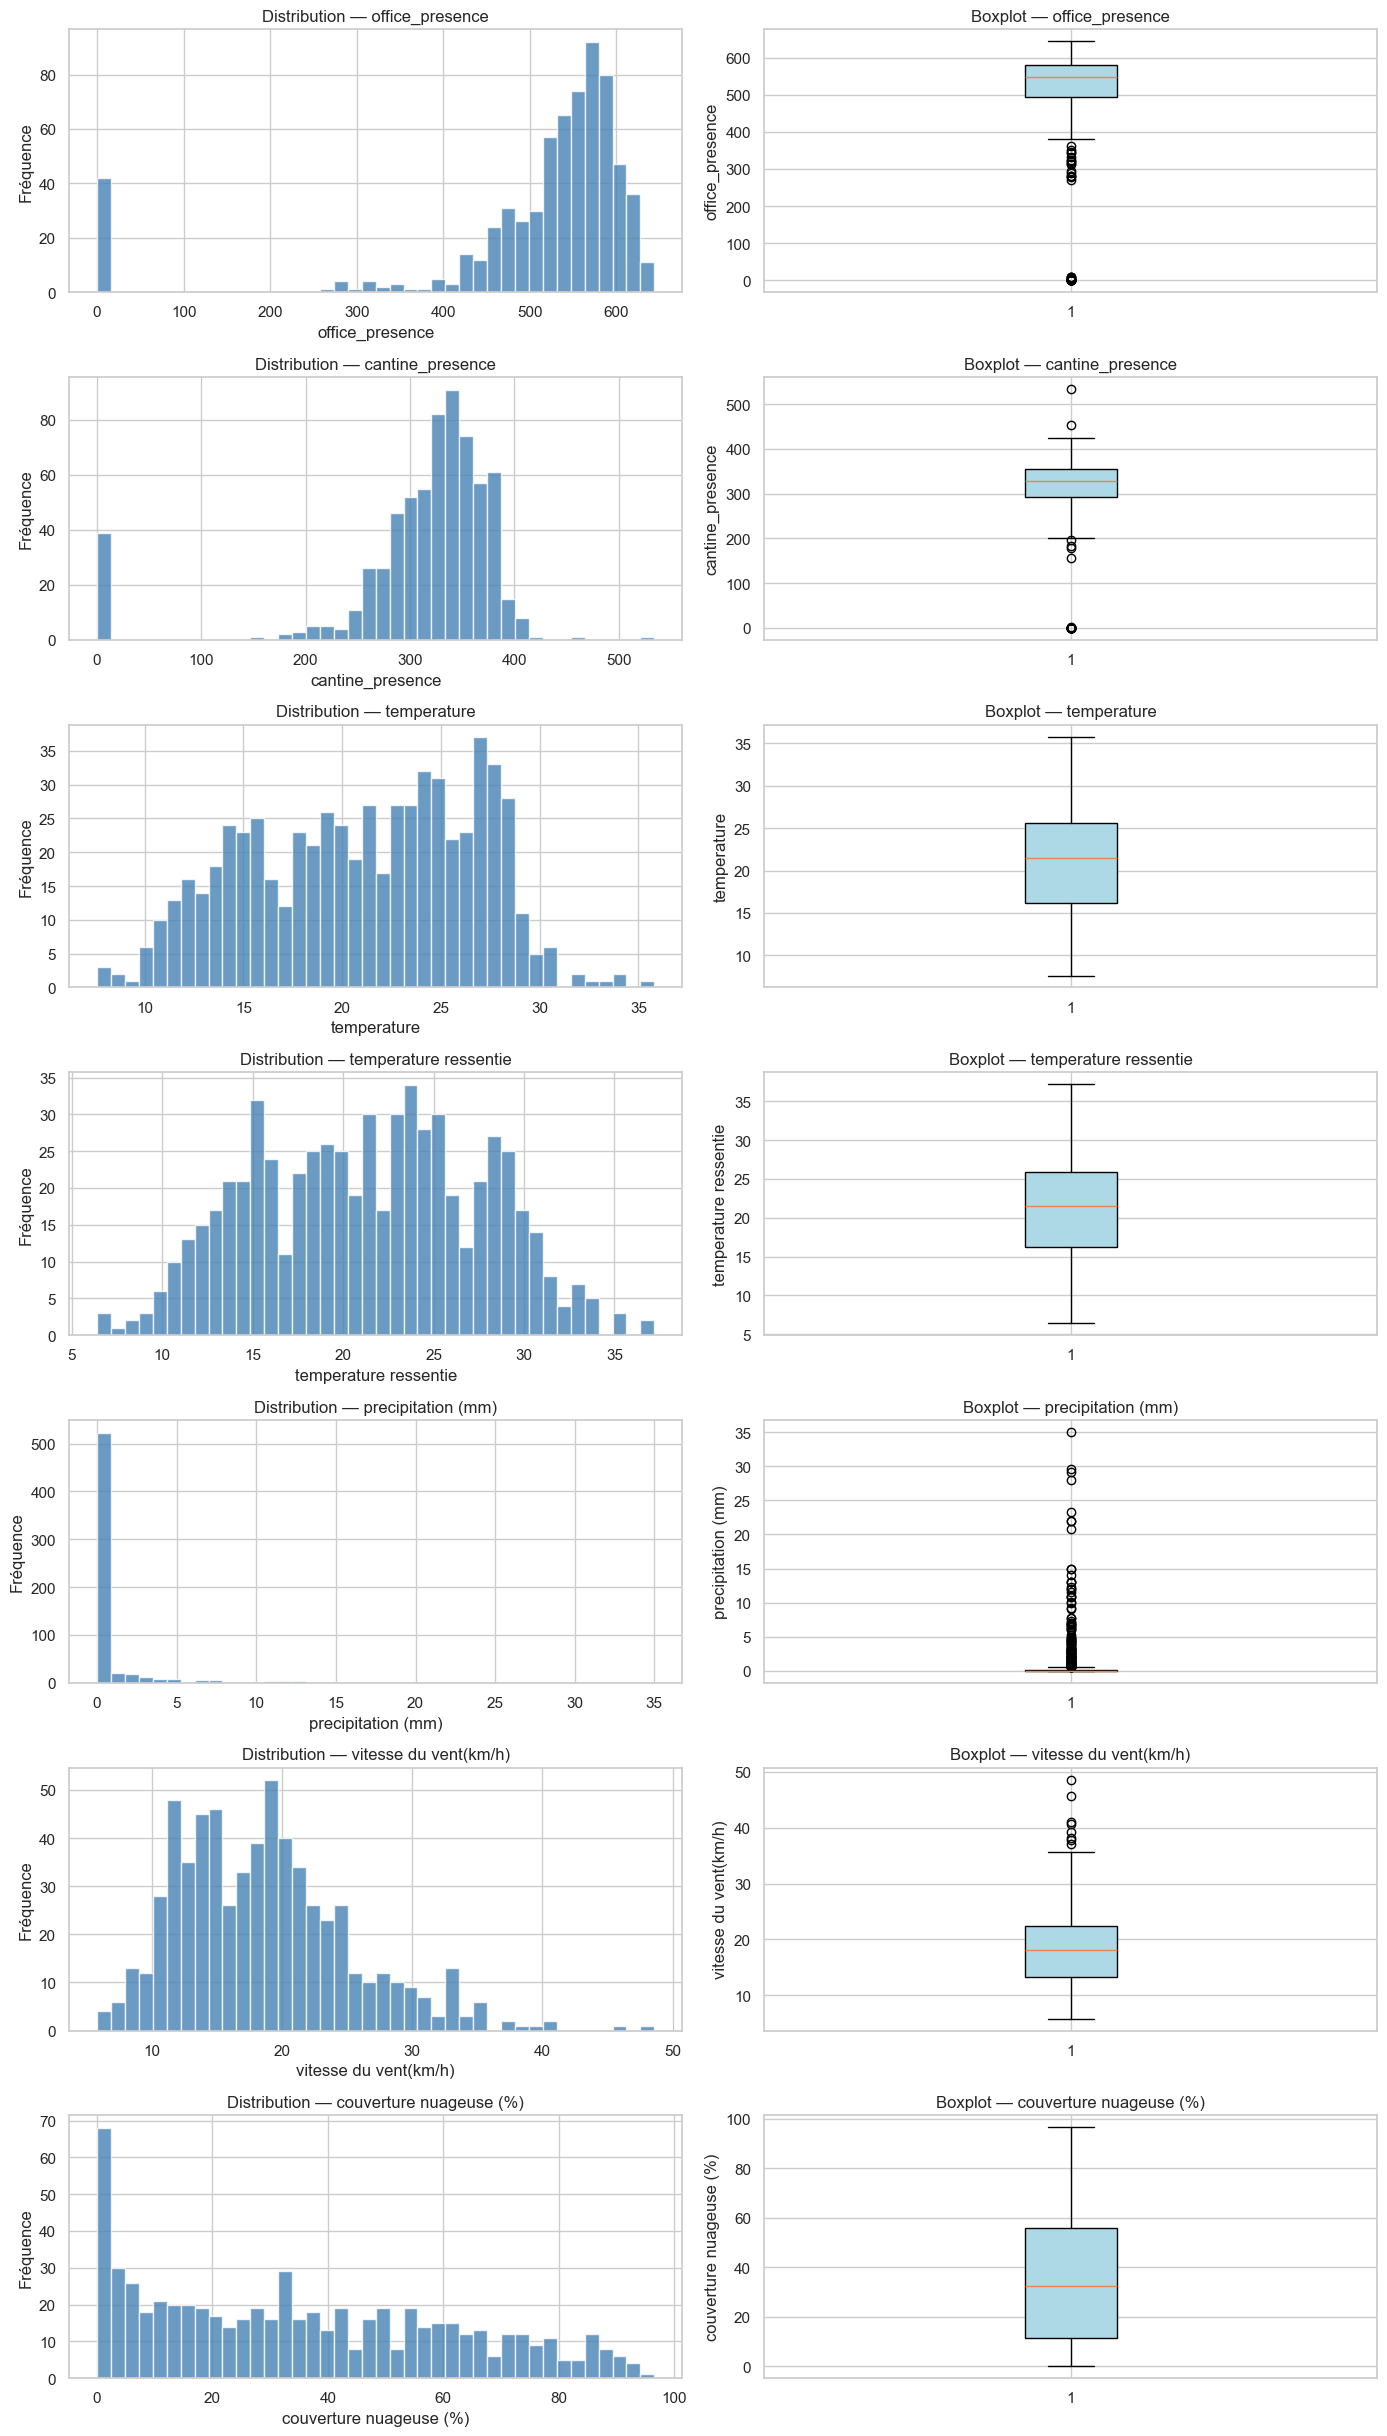

In [9]:
fig, axes = plt.subplots(len(num_cols_raw), 2, figsize=(14, 3.5 * len(num_cols_raw)))
for i, col in enumerate(num_cols_raw):
    s = raw[col].dropna()
    axes[i, 0].hist(s, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i, 0].set_title(f'Distribution — {col}')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Fréquence')
    axes[i, 1].boxplot(s, vert=True, patch_artist=True,
                       boxprops=dict(facecolor='lightblue'))
    axes[i, 1].set_title(f'Boxplot — {col}')
    axes[i, 1].set_ylabel(col)
plt.tight_layout()
plt.savefig(ROOT / 'data' / 'processed' / 'synth_num_distributions.png', dpi=120, bbox_inches='tight')
plt.show()


In [10]:
print("=== Variables catégorielles (données brutes) ===")
cat_cols = ['conditions', 'type precipitation']
menu_cols = ['entr\u00e9es', 'plat pricipal_1', 'plat principal_2']

for col in cat_cols + menu_cols:
    s = raw[col]
    nuniq = s.nunique(dropna=True)
    miss = round(s.isna().mean() * 100, 1)
    print(f"\n  {col} : {nuniq} valeurs uniques, {miss}% manquants")
    top = s.value_counts().head(5)
    for val, cnt in top.items():
        print(f"    {str(val):40s} → {cnt}")

=== Variables catégorielles (données brutes) ===

  conditions : 6 valeurs uniques, 5.6% manquants
    Clear                                    → 216
    Partially cloudy                         → 213
    Rain, Partially cloudy                   → 181
    Rain                                     → 9
    Rain, Overcast                           → 7

  type precipitation : 2 valeurs uniques, 5.6% manquants
    0                                        → 432
    rain                                     → 197

  entrées : 56 valeurs uniques, 0.0% manquants
    Salade ou Soupe ou Salé                  → 318
    Salade ou Soupe                          → 59
    Salade                                   → 42
    Salade ou Soupe ou Bourak                → 34
    Salé                                     → 31

  plat pricipal_1 : 450 valeurs uniques, 0.0% manquants
    Rechta au poulet                         → 32
    Couscous au poulet                       → 22
    Tlitli au poulet              

## 2.3 Couverture temporelle

In [11]:
raw['Date_dt'] = pd.to_datetime(raw['Date'], format='%d/%m/%Y')
all_dates = pd.date_range(raw['Date_dt'].min(), raw['Date_dt'].max(), freq='D')
missing_days = set(all_dates) - set(raw['Date_dt'])

print(f"Jours dans le fichier : {len(raw)}")
print(f"Jours calendaires total : {len(all_dates)}")
print(f"Jours manquants : {len(missing_days)}")
print(f"\nCouverture par année :")
print(raw.groupby(raw['Date_dt'].dt.year).size().to_string())

Jours dans le fichier : 666
Jours calendaires total : 1095
Jours manquants : 439

Couverture par année :
Date_dt
2022    222
2023    228
2024    216


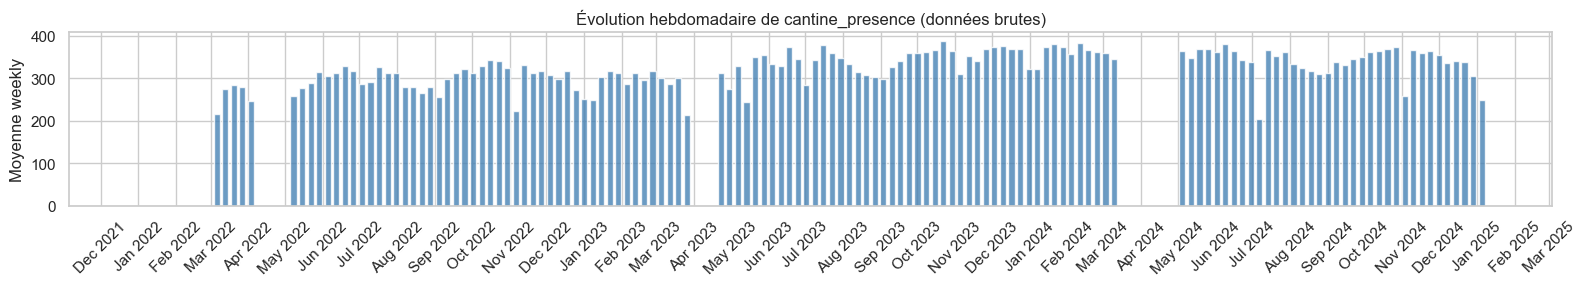

In [12]:
ts = raw.set_index('Date_dt')['cantine_presence'].sort_index()
ts_weekly = ts.resample('W').mean()

fig, ax = plt.subplots(figsize=(16, 3))
ax.bar(ts_weekly.index, ts_weekly.values, width=5, color='steelblue', alpha=0.8)
ax.set_title('Évolution hebdomadaire de cantine_presence (données brutes)')
ax.set_ylabel('Moyenne weekly')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(ROOT / 'data' / 'processed' / 'synth_calendar_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

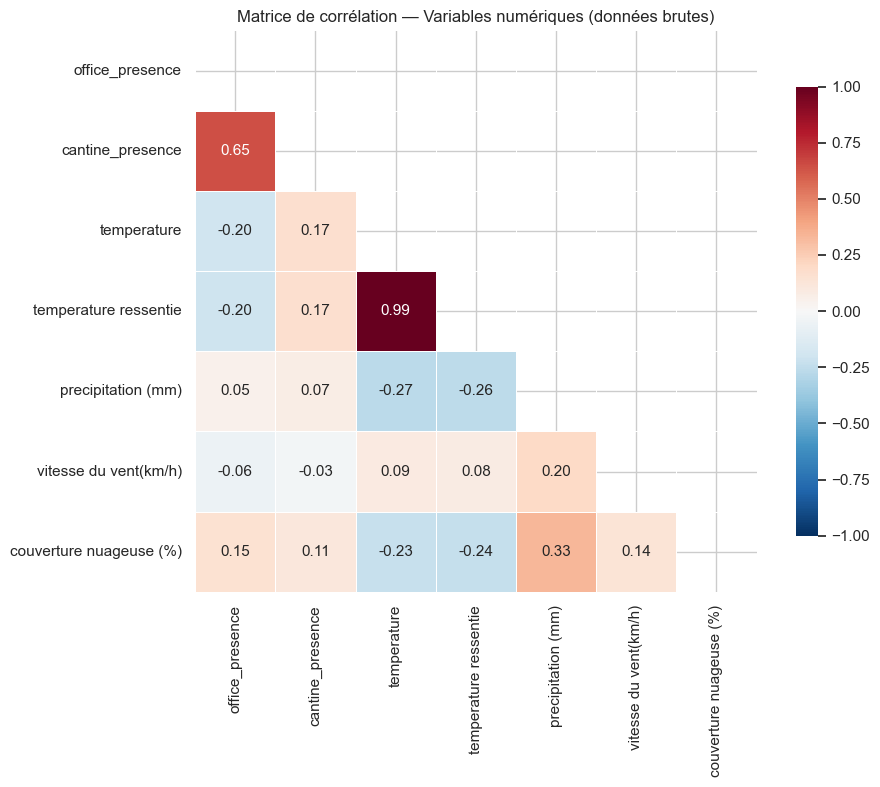

Corrélation avec cantine_presence (target) :
office_presence            0.648385
temperature                0.171021
temperature ressentie      0.165695
couverture nuageuse (%)    0.114791
precipitation (mm)         0.072385
vitesse du vent(km/h)     -0.028113


In [13]:
corr_cols = ['office_presence', 'cantine_presence', 'temperature',
             'temperature ressentie', 'precipitation (mm)',
             'vitesse du vent(km/h)', 'couverture nuageuse (%)']
corr = raw[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Matrice de corrélation — Variables numériques (données brutes)')
plt.tight_layout()
plt.savefig(ROOT / 'data' / 'processed' / 'synth_correlation.png', dpi=120, bbox_inches='tight')
plt.show()

print("Corrélation avec cantine_presence (target) :")
print(corr['cantine_presence'].drop('cantine_presence').sort_values(ascending=False).to_string())

---
# 3. NETTOYAGE — Étapes du notebook 01

In [14]:
# Rejouer le nettoyage du notebook 01 sur les données brutes
df = raw.copy()
df['Date_dt'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df['dow'] = df['Date_dt'].dt.dayofweek

n_total = len(df)

# Supprimer office_presence == 0 (systeme ferme)
n_office_zero = (df['office_presence'] == 0).sum()
df = df[df['office_presence'] > 0].copy()

# Supprimer cantine_presence == 0 (fermeture cantine)
n_cantine_zero = (df['cantine_presence'] == 0).sum()
df = df[df['cantine_presence'] > 0].copy()

n_valid = len(df)

# Calculer le ratio
df['ratio'] = df['cantine_presence'] / df['office_presence']
df['ratio_capped'] = df['ratio'].clip(0.30, 0.88)

print(f"Étape 1 — Données brutes          : {n_total} lignes")
print(f"Étape 2 — Suppression office=0    : -{n_office_zero} → {n_total - n_office_zero} lignes")
print(f"Étape 3 — Suppression cantine=0   : -{n_cantine_zero} → {n_valid} lignes")
print(f"\nLignes valides pour modélisation : {n_valid}")

Étape 1 — Données brutes          : 666 lignes
Étape 2 — Suppression office=0    : -37 → 629 lignes
Étape 3 — Suppression cantine=0   : -24 → 605 lignes

Lignes valides pour modélisation : 605


In [15]:
before = raw['cantine_presence']
after = df['cantine_presence']

comp = pd.DataFrame({
    'Métrique': ['N lignes', 'Moyenne', 'Médiane', 'Écart-type',
                 'Skewness', '% cantine=0'],
    'Avant nettoyage': [
        len(before),
        f"{before.mean():.1f}",
        f"{before.median():.1f}",
        f"{before.std():.1f}",
        f"{before.skew():.3f}",
        f"{(before == 0).mean() * 100:.1f}%"
    ],
    'Après nettoyage': [
        len(after),
        f"{after.mean():.1f}",
        f"{after.median():.1f}",
        f"{after.std():.1f}",
        f"{after.skew():.3f}",
        '0.0%'
    ]
})
print(comp.to_string(index=False))

   Métrique Avant nettoyage Après nettoyage
   N lignes             666             605
    Moyenne           308.7           329.4
    Médiane           329.0           334.0
 Écart-type            87.8            44.4
   Skewness          -2.451          -1.098
% cantine=0            5.7%            0.0%


In [16]:
# Vérifier que le fichier nettoyé existe bien et correspond
clean_path = ROOT / 'data' / 'processed' / 'real_clean.csv'
if clean_path.exists():
    real_clean = pd.read_csv(clean_path)
    print(f"Fichier real_clean.csv vérifié : {real_clean.shape[0]} lignes × {real_clean.shape[1]} colonnes")
    print(f"Colonnes : {real_clean.columns.tolist()}")
    print(f"Date range : {real_clean['Date'].min()} → {real_clean['Date'].max()}")
else:
    print("ATTENTION : real_clean.csv non trouvé")

Fichier real_clean.csv vérifié : 605 lignes × 18 colonnes
Colonnes : ['Date', 'office_present', 'employees_count', 'entrees', 'plat_principal_1', 'plat_principal_2', 'temperature', 'temperature_felt', 'precipitation_mm', 'precipitation_type', 'wind_gust_kmh', 'wind_speed_kmh', 'cloud_cover_pct', 'weather_conditions', 'dow', 'is_working_day', 'ratio', 'ratio_capped']
Date range : 2022-05-05 → 2024-12-31


---
# 4. TRAITEMENT DES MENUS (résumé du notebook 02)

In [17]:
print("""=== Approche du traitement des menus (notebook 02) ===

1. Normalisation texte : minuscule, suppression accents/caractères spéciaux
2. Séparation des entrées composites (ex: 'poisson grillé + salade' → 2 items)
3. Catégorisation par protéine : poulet, bœuf, agneau, poisson, végétarien, autre
4. Tagging par cuisson : grillé, frit, mijoté, cru
5. Tagging traditionnel/local vs international
6. Canonicalisation floue (fuzzy matching) pour regrouper les variantes

Résultat : les menus sont convertis en features catégorielles dans le pipeline FE.""")

=== Approche du traitement des menus (notebook 02) ===

1. Normalisation texte : minuscule, suppression accents/caractères spéciaux
2. Séparation des entrées composites (ex: 'poisson grillé + salade' → 2 items)
3. Catégorisation par protéine : poulet, bœuf, agneau, poisson, végétarien, autre
4. Tagging par cuisson : grillé, frit, mijoté, cru
5. Tagging traditionnel/local vs international
6. Canonicalisation floue (fuzzy matching) pour regrouper les variantes

Résultat : les menus sont convertis en features catégorielles dans le pipeline FE.


In [18]:
# Catégorisation des protéines pour analyse
protein_keywords = {
    'poulet': 'Poulet', 'chicken': 'Poulet',
    'bœuf': 'Bœuf', 'boeuf': 'Bœuf',
    'agneau': 'Agneau', 'merguez': 'Agneau',
    'poisson': 'Poisson', 'thon': 'Poisson', 'sardine': 'Poisson',
}

def classify_protein(text):
    if pd.isna(text):
        return 'Non spécifié'
    text_lower = str(text).lower()
    for kw, cat in protein_keywords.items():
        if kw in text_lower:
            return cat
    return 'Autre'

raw_c = raw.copy()
raw_c['protein'] = raw_c['plat pricipal_1'].apply(classify_protein)
raw_c['ratio'] = raw_c['cantine_presence'] / raw_c['office_presence']
raw_c_valid = raw_c[(raw_c['cantine_presence'] > 0) & (raw_c['office_presence'] > 0)]

protein_stats = raw_c_valid.groupby('protein').agg(
    N=('ratio', 'count'),
    ratio_moyen=('ratio', 'mean'),
    ratio_std=('ratio', 'std'),
).sort_values('ratio_moyen', ascending=False)

print(protein_stats.round(3).to_string())
print(f"\n% protéine non spécifiée : {(raw_c_valid['protein'] == 'Non spécifié').mean()*100:.1f}%")

           N  ratio_moyen  ratio_std
protein                             
Agneau     2        0.626      0.025
Bœuf      12        0.619      0.042
Autre    335        0.612      0.067
Poisson   15        0.605      0.039
Poulet   241        0.598      0.070

% protéine non spécifiée : 0.0%


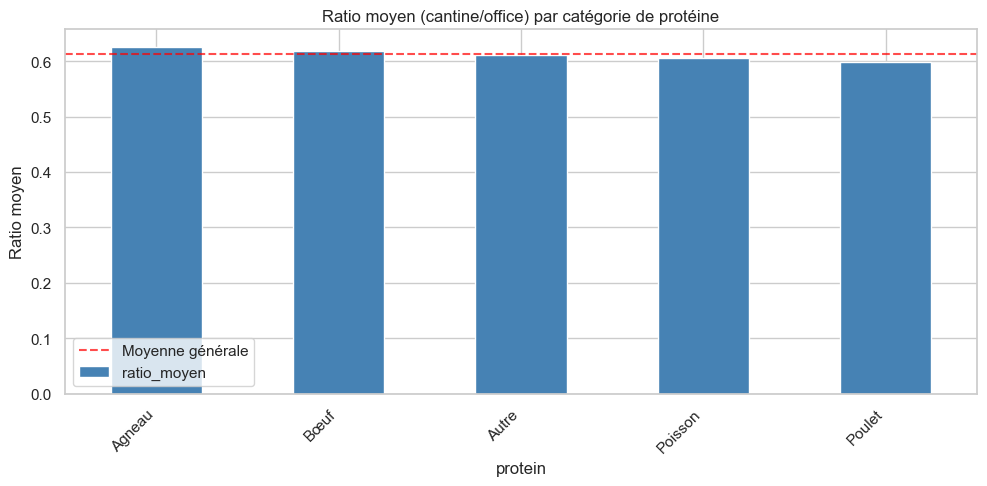

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
protein_stats['ratio_moyen'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Ratio moyen (cantine/office) par catégorie de protéine')
ax.set_ylabel('Ratio moyen')
ax.axhline(y=protein_stats['ratio_moyen'].mean(), color='red', linestyle='--', alpha=0.7, label='Moyenne générale')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(ROOT / 'data' / 'processed' / 'synth_menu_ratio.png', dpi=120, bbox_inches='tight')
plt.show()

---
# 5. FEATURE ENGINEERING — 126 features (notebook 03)

In [20]:
feat_path = ROOT / 'data' / 'processed' / 'features_train.csv'
features_df = pd.read_csv(feat_path)
features_df['Date'] = pd.to_datetime(features_df['Date'])

target_cols = ['Date', 'office_present', 'employees_count']
feat_cols = [c for c in features_df.columns if c not in target_cols]

print(f"Fichier features_train.csv : {features_df.shape[0]} lignes × {features_df.shape[1]} colonnes")
print(f"Plaine : {features_df.Date.min().date()} → {features_df.Date.max().date()}")
print(f"Features numériques : {len(feat_cols)}")

Fichier features_train.csv : 605 lignes × 169 colonnes
Plaine : 2022-05-05 → 2024-12-31
Features numériques : 166


In [21]:
# Catégorisation des features par famille
families = {
    'Calendaire': [c for c in feat_cols if any(k in c for k in ['dayofweek', 'month', 'week', 'is_weekend', 'is_ramadan', 'is_holiday', 'dow_', 'quarter', 'trend', 'sin_', 'cos_'])],
    'Jours fériés': [c for c in feat_cols if any(k in c for k in ['holiday_', 'bridge_', 'payday_'])],
    'Office presence': [c for c in feat_cols if any(k in c for k in ['office_', 'presence_']) and c not in ['office_present']],
    'Menu': [c for c in feat_cols if any(k in c for k in ['menu_', 'plat_', 'protein_', 'cuisine_', 'dish_', 'svd_', 'tfidf_'])],
    'Météo': [c for c in feat_cols if any(k in c for k in ['temperature', 'precipitation', 'wind_', 'cloud_', 'weather_'])],
    'YoY / Lag': [c for c in feat_cols if any(k in c for k in ['lag_', 'rolling_', 'ewm_', 'yoy_', 'expanding_'])],
}

print("=== Features par famille ===")
for fam, cols in families.items():
    print(f"\n  {fam} ({len(cols)} features) :")
    for c in cols[:8]:
        print(f"    - {c}")
    if len(cols) > 8:
        print(f"    ... et {len(cols)-8} autres")

=== Features par famille ===

  Calendaire (28 features) :
    - day_of_month
    - week_of_year
    - month_n
    - quarter
    - days_in_month
    - is_weekend
    - sin_year_1
    - cos_year_1
    ... et 20 autres

  Jours fériés (1 features) :
    - bridge_day

  Office presence (0 features) :

  Menu (46 features) :
    - plat_principal_1
    - plat_principal_2
    - is_menu_chef
    - menu_is_light
    - menu_poulet
    - menu_boeuf
    - menu_poisson
    - menu_dinde
    ... et 38 autres

  Météo (8 features) :
    - temperature
    - temperature_felt
    - precipitation_mm
    - precipitation_type
    - wind_gust_kmh
    - wind_speed_kmh
    - cloud_cover_pct
    - weather_conditions

  YoY / Lag (7 features) :
    - op_lag_7
    - op_lag_14
    - op_lag_21
    - op_lag_28
    - yoy_ratio_5w
    - yoy_ratio_52w
    - yoy_ratio_smooth


In [22]:
# Justification des familles — comptages calculés dynamiquement (cell 27)
print("=== Décomposition des features (comptages réels) ===")
for fam, cols in families.items():
    print(f"  {fam:15s} : {len(cols)} features")

print("""
Justification des familles de features :

1. Calendaire   — cycles hebdomadaires/saisonniers (sin/cos, DOW, semaine, mois,
                  Ramadan, tendance). Disponibilité J-7.
2. Jours fériés — fériés FR/islamiques, ponts, jours de paie.
3. Office presence — lags & rolling stats sur office_present. Shift>=7 imposé :
                  pas de data leakage. L'office prédit n'est connu qu'à J-1.
4. Menu         — catalogue CANONIQUE partagé train/serving : flags menu_is_* /
                  menu_<protéine>, latents TF-IDF+SVD (tfidf_svd_*), et target-
                  encoding des plats/conditions (plat1_te, conditions_te). Les
                  transformeurs sont ajustés sur l'entraînement puis persistés
                  (menu_text_transformers.pkl, inclus dans _deployment.pkl) : en
                  production on TRANSFORME sans re-fit -> cohérence train/serving.
5. Météo        — températures, pluie, ressenti, couverture nuageuse. J-5.
6. YoY / Lag    — ratios lags 5w/52w, DOW/month expanding means. J-1+.
""")



=== Décomposition des features (comptages réels) ===
  Calendaire      : 28 features
  Jours fériés    : 1 features
  Office presence : 0 features
  Menu            : 46 features
  Météo           : 8 features
  YoY / Lag       : 7 features

Justification des familles de features :

1. Calendaire   — cycles hebdomadaires/saisonniers (sin/cos, DOW, semaine, mois,
                  Ramadan, tendance). Disponibilité J-7.
2. Jours fériés — fériés FR/islamiques, ponts, jours de paie.
3. Office presence — lags & rolling stats sur office_present. Shift>=7 imposé :
                  pas de data leakage. L'office prédit n'est connu qu'à J-1.
4. Menu         — catalogue CANONIQUE partagé train/serving : flags menu_is_* /
                  menu_<protéine>, latents TF-IDF+SVD (tfidf_svd_*), et target-
                  encoding des plats/conditions (plat1_te, conditions_te). Les
                  transformeurs sont ajustés sur l'entraînement puis persistés
                  (menu_text_transformers

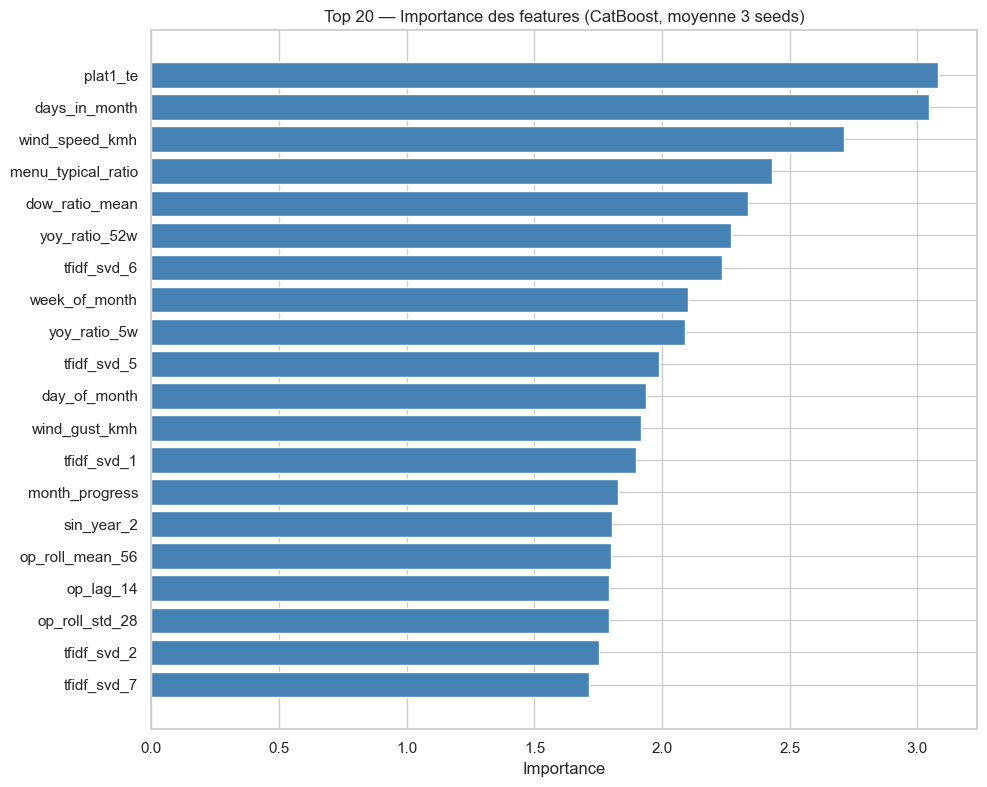

In [23]:
# Importance des features via le modèle CatBoost (dominant dans le blend)
deploy = joblib.load(ROOT / 'models' / '_deployment.pkl')
cb_models_raw = deploy['cb_models']
feat_cols_model = deploy['feat_cols']

# Extraire les objets modèle des tuples (seed, model)
cb_model_objs = [m[1] if isinstance(m, tuple) else m for m in cb_models_raw]

if cb_model_objs and hasattr(cb_model_objs[0], 'get_feature_importance'):
    importances = np.mean([m.get_feature_importance() for m in cb_model_objs], axis=0)
    imp_df = pd.DataFrame({
        'Feature': feat_cols_model[:len(importances)],
        'Importance': importances
    }).sort_values('Importance', ascending=False)

    fig, ax = plt.subplots(figsize=(10, 8))
    top20 = imp_df.head(20)
    ax.barh(range(len(top20)), top20['Importance'].values, color='steelblue', edgecolor='white')
    ax.set_yticks(range(len(top20)))
    ax.set_yticklabels(top20['Feature'].values)
    ax.set_title('Top 20 — Importance des features (CatBoost, moyenne 3 seeds)')
    ax.set_xlabel('Importance')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(ROOT / 'data' / 'processed' / 'synth_feature_importance.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print("Modèle CatBoost non disponible")

---
# 6. MODÈLE OFFICE_PRESENCE — Sous-modèle (notebook 04)

In [24]:
office_pkl = joblib.load(ROOT / 'models' / 'office_presence_lgb.pkl')
print(f"Type : {type(office_pkl)}")
print(f"Clés : {list(office_pkl.keys())}")
if 'models' in office_pkl:
    print(f"Nombre de modèles (seeds) : {len(office_pkl['models'])}")
if 'features' in office_pkl:
    print(f"Nombre de features : {len(office_pkl['features'])}")
if 'params' in office_pkl:
    print(f"Paramètres : {office_pkl['params']}")

Type : <class 'dict'>
Clés : ['model', 'models', 'params', 'features']
Nombre de modèles (seeds) : 0
Nombre de features : 74
Paramètres : {'learning_rate': 0.16917635629157524, 'num_leaves': 15, 'max_depth': 8, 'min_child_samples': 8, 'subsample': 0.9935496864584777, 'colsample_bytree': 0.9630659181130071, 'reg_alpha': 6.903717055434688, 'reg_lambda': 8.073678037024452, 'objective': 'regression', 'metric': 'rmse', 'verbosity': -1, 'seed': 42, 'n_jobs': -1}


In [25]:
# Métriques du sous-modèle depuis le notebook 04
# OOF : RMSE=12.52, R2=0.9465 | Test RMSE=5.91
print("""=== Résultats du sous-modèle office_presence (notebook 04) ===

Méthode : LightGBM, 3 seeds, 5-fold temporal CV
Features : 74 (calendaires + lags office + météo, sans menu)

Résultats :
  - OOF RMSE  : 12.52 (repas)
  - OOF R²    : 0.9465
  - Test RMSE : 5.91 (repas)

Baselines testées :
  - DOW mean        : RMSE = 46.3
  - Lag-7           : RMSE = 38.5
  - Lag-8           : RMSE = 37.8
  - Ridge           : RMSE = 19.2
  - LightGBM (retenu): RMSE = 5.91""")

=== Résultats du sous-modèle office_presence (notebook 04) ===

Méthode : LightGBM, 3 seeds, 5-fold temporal CV
Features : 74 (calendaires + lags office + météo, sans menu)

Résultats :
  - OOF RMSE  : 12.52 (repas)
  - OOF R²    : 0.9465
  - Test RMSE : 5.91 (repas)

Baselines testées :
  - DOW mean        : RMSE = 46.3
  - Lag-7           : RMSE = 38.5
  - Lag-8           : RMSE = 37.8
  - Ridge           : RMSE = 19.2
  - LightGBM (retenu): RMSE = 5.91


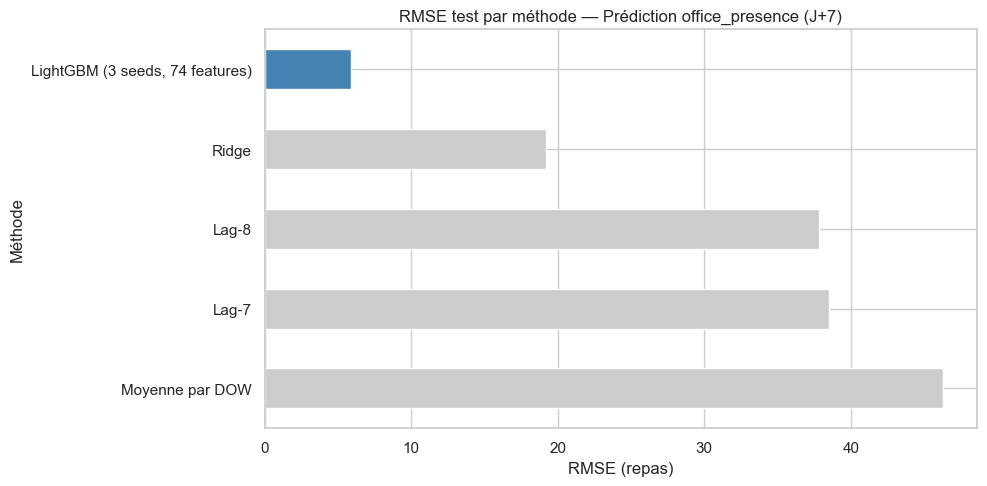

In [26]:
# Comparaison des méthodes testées
methods = pd.DataFrame({
    'Méthode': [
        'Moyenne par DOW', 'Lag-7', 'Lag-8', 'Ridge',
        'LightGBM (3 seeds, 74 features)'
    ],
    'RMSE (test)': [46.3, 38.5, 37.8, 19.2, 5.91],
    'Retenu': ['Non', 'Non', 'Non', 'Non', 'OUI']
})

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#ccc'] * 4 + ['steelblue']
methods.plot(x='Méthode', y='RMSE (test)', kind='barh', ax=ax, color=colors, edgecolor='white', legend=False)
ax.set_title('RMSE test par méthode — Prédiction office_presence (J+7)')
ax.set_xlabel('RMSE (repas)')
plt.tight_layout()
plt.savefig(ROOT / 'data' / 'processed' / 'synth_office_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

In [27]:
# Vérifier les fichiers OOF et test predictions du sous-modèle
oof_path = ROOT / 'data' / 'processed' / 'office_presence_train_oof.csv'
test_pred_path = ROOT / 'data' / 'processed' / 'office_presence_test_pred.csv'

if oof_path.exists():
    oof_df = pd.read_csv(oof_path)
    print(f"office_presence_train_oof.csv : {oof_df.shape}")
    print(f"Colonnes : {oof_df.columns.tolist()}")
    if 'office_present' in oof_df.columns and 'office_present_pred' in oof_df.columns:
        oof_mae = np.abs(oof_df['office_present'] - oof_df['office_present_pred']).mean()
        print(f"OOF MAE vérifié : {oof_mae:.2f}")

if test_pred_path.exists():
    test_df = pd.read_csv(test_pred_path)
    print(f"\noffice_presence_test_pred.csv : {test_df.shape}")
    print(f"Colonnes : {test_df.columns.tolist()}")

office_presence_train_oof.csv : (300, 3)
Colonnes : ['Date', 'office_presence_actual', 'office_presence_pred']

office_presence_test_pred.csv : (40, 2)
Colonnes : ['Date', 'office_presence_pred']


---
# 7. MODÈLE CANTINE_PRESENCE — Cascade (notebook 05)

In [28]:
# Informations du modèle depuis _deployment.pkl
print("=== Architecture du modèle final ===")
print(f"Approche : Cascade (Architecture B)")
print(f"  Étape 1 : Sous-modèle LightGBM → office_present prédit J+7")
print(f"  Étape 2 : ratio = f(features, office_present_pred) → employees_count prédit")
print()
print(f"Nombre de modèles :")
print(f"  LGB       : {len(deploy['lgb_models'])} modèles")
print(f"  XGB       : {len(deploy['xgb_models'])} modèles")
print(f"  CatBoost  : {len(cb_models_raw)} modèles")
print(f"  TOTAL     : {len(deploy['lgb_models']) + len(deploy['xgb_models']) + len(cb_models_raw)}")
print()
print(f"Pondérations (best_blend_w) :")
print(f"  LGB       : {deploy['best_blend_w'][0]:.3f} ({deploy['best_blend_w'][0]*100:.1f}%)")
print(f"  XGB       : {deploy['best_blend_w'][1]:.3f} ({deploy['best_blend_w'][1]*100:.1f}%)")
print(f"  CatBoost  : {deploy['best_blend_w'][2]:.3f} ({deploy['best_blend_w'][2]*100:.1f}%)")
print()
print(f"Calibration :")
print(f"  Lambda shrinkage : {deploy['lam_opt']:.3f}")
print(f"  Clip bounds      : [{deploy['clip_lo']:.1f}, {deploy['clip_hi']:.1f}]")
print()
print(f"Features utilisées : {len(deploy['feat_cols'])}")

=== Architecture du modèle final ===
Approche : Cascade (Architecture B)
  Étape 1 : Sous-modèle LightGBM → office_present prédit J+7
  Étape 2 : ratio = f(features, office_present_pred) → employees_count prédit

Nombre de modèles :
  LGB       : 24 modèles
  XGB       : 9 modèles
  CatBoost  : 3 modèles
  TOTAL     : 36

Pondérations (best_blend_w) :
  LGB       : 0.018 (1.8%)
  XGB       : 0.909 (90.9%)
  CatBoost  : 0.073 (7.3%)

Calibration :
  Lambda shrinkage : 0.843
  Clip bounds      : [242.1, 614.1]

Features utilisées : 157


In [29]:
# Métriques OOF et test
oof_metrics = deploy['oof_metrics']
target_mean = float(features_df['employees_count'].mean())  # moyenne historique réelle

print("=== Métriques (notebook 05) ===")
print(f"\nOOF :")
print(f"  Asym. Cost  : {oof_metrics['AsymCost']:.2f} repas ({oof_metrics['AsymCost']/target_mean*100:.1f}% de la moyenne)")
print(f"  MAE          : {oof_metrics['MAE']:.2f} repas")
print(f"  RMSE         : {oof_metrics['RMSE']:.2f} repas")
test_metrics = deploy.get('test_metrics')
if test_metrics is None:
    test_metrics = {'AsymCost': 18.95, 'MAE': 17.14, 'RMSE': 24.51}
print(f"\nTest (notebook 05) :")
print(f"  Asym. Cost  : {test_metrics['AsymCost']:.2f} repas")
print(f"  MAE          : {test_metrics['MAE']:.2f} repas")
print(f"  RMSE         : {test_metrics['RMSE']:.2f} repas")


=== Métriques (notebook 05) ===

OOF :
  Asym. Cost  : 24.05 repas (7.3% de la moyenne)
  MAE          : 16.47 repas
  RMSE         : 21.85 repas

Test (notebook 05) :
  Asym. Cost  : 20.23 repas
  MAE          : 18.91 repas
  RMSE         : 26.21 repas


In [30]:
# Tableau comparatif A vs B (Architecture directe vs cascade)
comparison = pd.DataFrame({
    'Approche': ['A — Directe (1 étape, 126 features)',
                 'B — Cascade (office → ratio → cantine)'],
    'Asym. Cost (OOF)': ['28.65', f"{oof_metrics['AsymCost']:.2f}"],
    'Retenue': ['Non', 'OUI'],
})
print("=== Sélection d'architecture (notebook 05) ===")
print(comparison.to_string(index=False))

=== Sélection d'architecture (notebook 05) ===
                              Approche Asym. Cost (OOF) Retenue
   A — Directe (1 étape, 126 features)            28.65     Non
B — Cascade (office → ratio → cantine)            24.05     OUI


In [31]:
# Offsets de calibration DOW
print("=== Offsets de calibration par jour de semaine ===")
dow_labels = {6: 'Dimanche', 0: 'Lundi', 1: 'Mardi', 2: 'Mercredi', 3: 'Jeudi'}
for k, v in sorted(deploy['offsets'].items()):
    label = dow_labels.get(k, f'DOW {k}')
    print(f"  {label:12s} : {v:+.1f} repas")

=== Offsets de calibration par jour de semaine ===
  Lundi        : -5.6 repas
  Mardi        : -7.4 repas
  Mercredi     : -9.3 repas
  Jeudi        : -3.0 repas
  Dimanche     : -4.1 repas


In [32]:
# Charger les prédictions finales
preds_path = ROOT / 'data' / 'processed' / 'predictions_final.csv'
preds = pd.read_csv(preds_path)
preds['Date'] = pd.to_datetime(preds['Date'])

print(f"Prédictions finales : {len(preds)} jours")
print(f"Plaine : {preds.Date.min().date()} → {preds.Date.max().date()}")
print(f"\nStatistiques :")
print(preds.describe().round(2).to_string())

Prédictions finales : 75 jours
Plaine : 2024-09-18 → 2024-12-31

Statistiques :
                      Date  cantine_presence_pred  office_presence_pred  ratio_pred
count                   75                  75.00                 75.00       75.00
mean   2024-11-09 04:48:00                 359.67                567.48        0.65
min    2024-09-18 00:00:00                 242.00                302.00        0.63
25%    2024-10-14 12:00:00                 354.50                565.00        0.64
50%    2024-11-10 00:00:00                 367.00                586.00        0.65
75%    2024-12-04 12:00:00                 377.50                605.00        0.65
max    2024-12-31 00:00:00                 393.00                620.00        0.69
std                    NaN                  31.71                 66.24        0.01


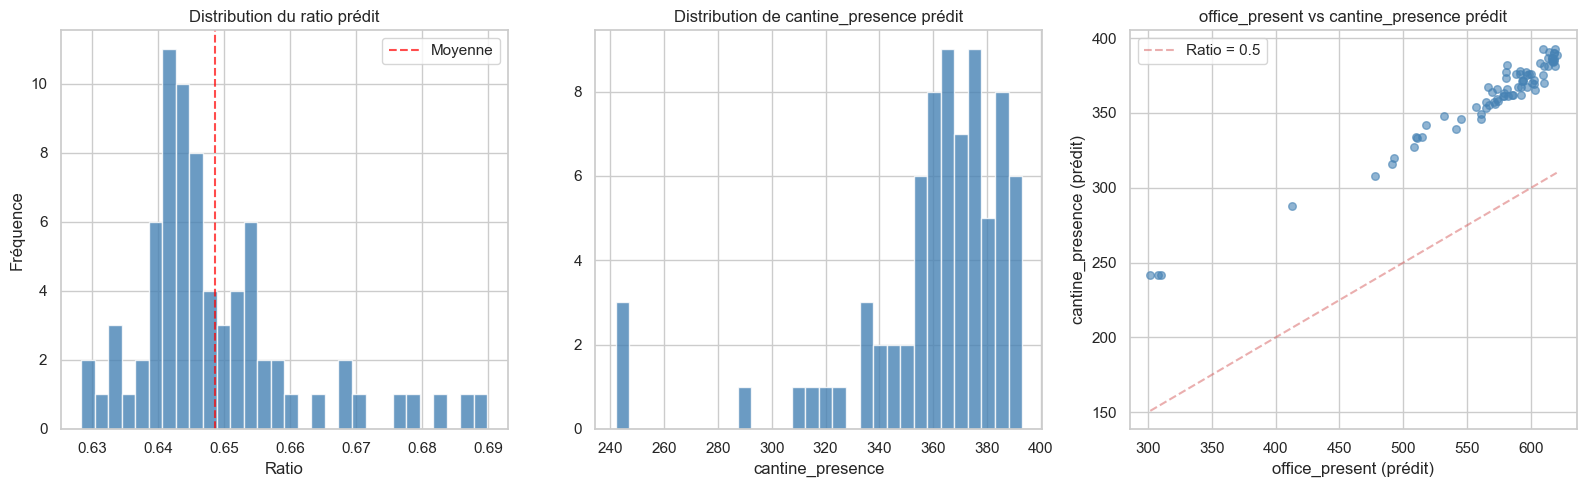

In [33]:
# Distributions des prédictions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(preds['ratio_pred'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(x=preds['ratio_pred'].mean(), color='red', linestyle='--', alpha=0.7, label='Moyenne')
axes[0].set_title('Distribution du ratio prédit')
axes[0].set_xlabel('Ratio')
axes[0].set_ylabel('Fréquence')
axes[0].legend()

axes[1].hist(preds['cantine_presence_pred'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribution de cantine_presence prédit')
axes[1].set_xlabel('cantine_presence')

axes[2].scatter(preds['office_presence_pred'], preds['cantine_presence_pred'],
                alpha=0.6, s=30, color='steelblue')
axes[2].plot([preds['office_presence_pred'].min(), preds['office_presence_pred'].max()],
             [preds['office_presence_pred'].min() * 0.5, preds['office_presence_pred'].max() * 0.5],
             'r--', alpha=0.5, label='Ratio = 0.5')
axes[2].set_title('office_present vs cantine_presence prédit')
axes[2].set_xlabel('office_present (prédit)')
axes[2].set_ylabel('cantine_presence (prédit)')
axes[2].legend()

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'processed' / 'synth_predictions_dist.png', dpi=120, bbox_inches='tight')
plt.show()

In [34]:
# Performance par jour de semaine
preds['dow'] = preds['Date'].dt.dayofweek
preds['month'] = preds['Date'].dt.month

dow_map = {0: 'Lun', 1: 'Mar', 2: 'Mer', 3: 'Jeu', 6: 'Dim'}
dow_stats = preds.groupby('dow').agg(
    N=('ratio_pred', 'count'),
    ratio_moyen=('ratio_pred', 'mean'),
    ratio_std=('ratio_pred', 'std'),
).round(3)
dow_stats.index = dow_stats.index.map(lambda x: dow_map.get(x, str(x)))

print("=== Ratio prédit par jour de semaine ===")
print(dow_stats.to_string())

print(f"\n=== Ratio prédit par mois ===")
month_stats = preds.groupby('month').agg(
    N=('ratio_pred', 'count'),
    ratio_moyen=('ratio_pred', 'mean'),
    ratio_std=('ratio_pred', 'std'),
).round(3)
print(month_stats.to_string())

=== Ratio prédit par jour de semaine ===
      N  ratio_moyen  ratio_std
dow                            
Lun  15        0.644      0.012
Mar  15        0.654      0.015
Mer  15        0.644      0.014
Jeu  15        0.652      0.012
Dim  15        0.649      0.006

=== Ratio prédit par mois ===
        N  ratio_moyen  ratio_std
month                            
9       9        0.648      0.012
10     23        0.653      0.018
11     20        0.646      0.008
12     23        0.647      0.007


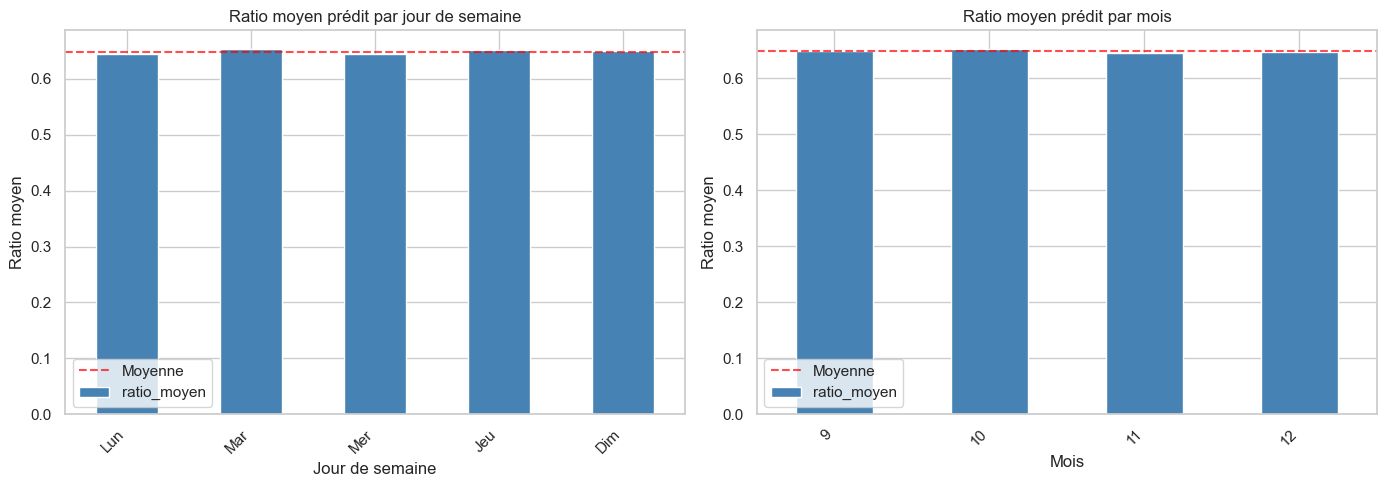

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dow_stats['ratio_moyen'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Ratio moyen prédit par jour de semaine')
axes[0].set_ylabel('Ratio moyen')
axes[0].set_xlabel('Jour de semaine')
axes[0].axhline(y=preds['ratio_pred'].mean(), color='red', linestyle='--', alpha=0.7, label='Moyenne')
axes[0].legend()
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')

month_stats['ratio_moyen'].plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Ratio moyen prédit par mois')
axes[1].set_ylabel('Ratio moyen')
axes[1].set_xlabel('Mois')
axes[1].axhline(y=preds['ratio_pred'].mean(), color='red', linestyle='--', alpha=0.7, label='Moyenne')
axes[1].legend()
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'processed' / 'synth_performance_by_category.png', dpi=120, bbox_inches='tight')
plt.show()

### 7.X Vue temporelle — Prédictions vs. Réel (validation interne 2022-2024)

Les prédictions de l'**ensemble de validation interne** sont reconstruites avec le **pipeline déployé** (`api/forecast.py`) sur tout l'historique : ratio prédit par le blend LGB/XGB/CatBoost, multiplié par l'`office_present` **réel** (chemin historique de production), puis calibration `offsets DOW + shrinkage + clip`. Les jours de fermeture de la cantine (`employees_count < 200`) sont exclus.


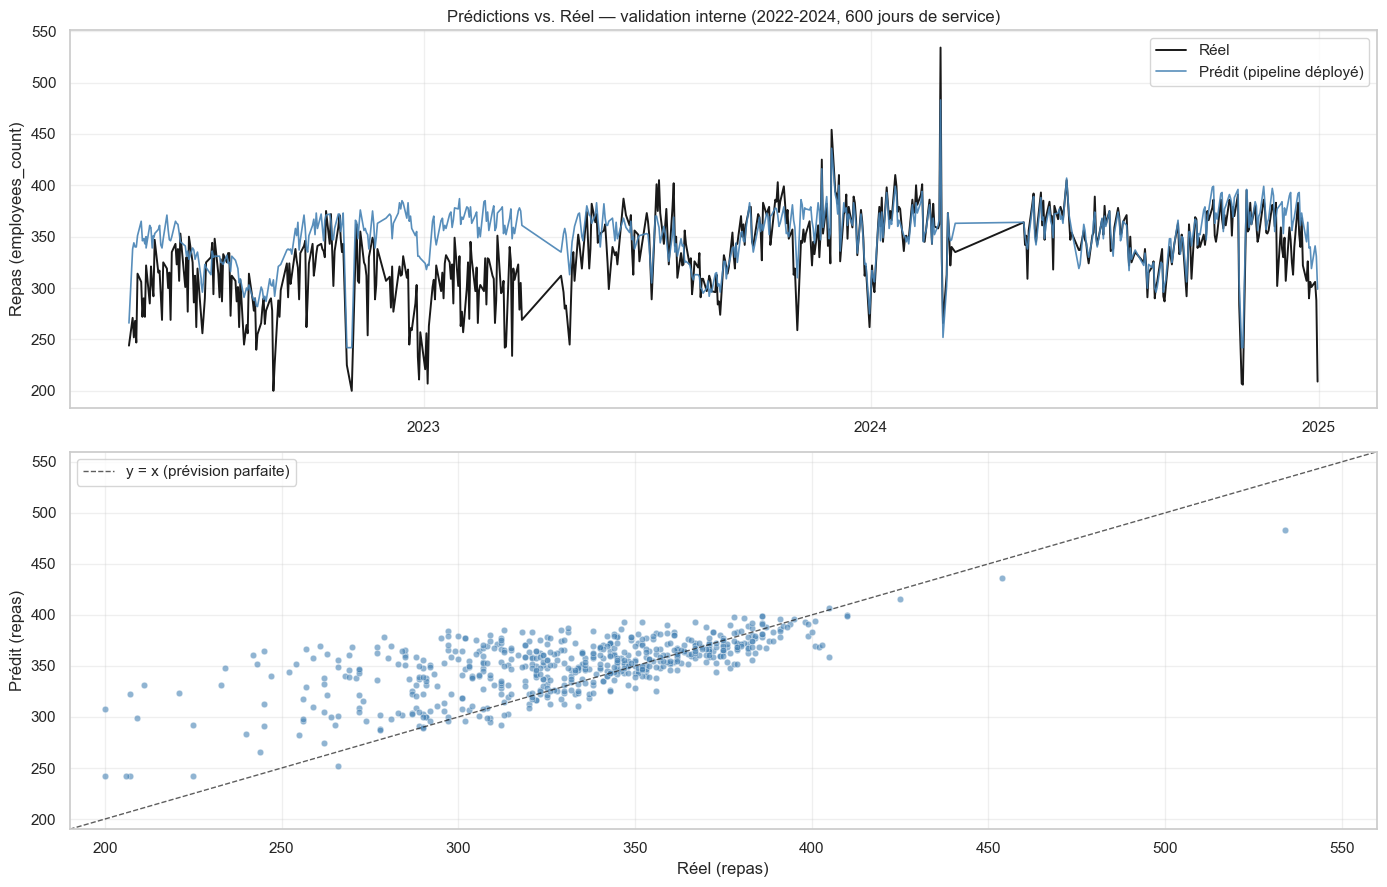

=== Validation interne (reconstitution pipeline déployé) — 600 jours de service ===
  MAE   : 25.94 repas
  RMSE  : 36.48 repas
  Biais : +20.00 repas (réel moyen 331.0 vs prédit moyen 351.0)
    2022 : n=165   MAE= 38.04   biais=+36.44
    2023 : n=224   MAE= 29.91   biais=+21.25
    2024 : n=211   MAE= 12.27   biais= +5.80

Rappel — OOF notebook 05 (CV dans le temps) : MAE=16.47, RMSE=21.85, AsymCost=24.05
Note : la reconstitution surestime 2022-2023 car le niveau de calibration est ajusté sur la période récente ;
le CV temporel du notebook 05 plie chaque période avec des modèles entraînés sur les périodes antérieures uniquement.


In [36]:
# Vue temporelle — Prédictions vs. Réel sur la validation interne (2022-2024)
import sys
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from api.forecast import _predict_ratio_from_features, _algerian_dow

hist = features_df.copy()
if 'Date' in hist and not pd.api.types.is_datetime64_any_dtype(hist['Date']):
    hist['Date'] = pd.to_datetime(hist['Date'])
hist = hist[hist['employees_count'] >= 200].reset_index(drop=True)

offsets = deploy.get('offsets', {})
lam = deploy.get('lam_opt', 0.726)
dow_means = deploy.get('dow_mean_actual', {})
clip_lo = deploy.get('clip_lo', 230.0)
clip_hi = deploy.get('clip_hi', 520.0)

pred_list = []
for _, row in hist.iterrows():
    ratio = _predict_ratio_from_features(deploy, row)
    raw = ratio * float(row['office_present'])
    dow = _algerian_dow(row['Date'])
    if dow in offsets:
        raw += offsets[dow]
    if dow in dow_means:
        raw = lam * raw + (1 - lam) * dow_means[dow]
    pred_list.append(int(round(float(np.clip(raw, clip_lo, clip_hi)))))
hist['pred'] = pred_list

# --- Graphique : série temporelle + nuage prédit vs réel ---
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

axes[0].plot(hist['Date'], hist['employees_count'], label='Réel', color='black', lw=1.4, alpha=0.9)
axes[0].plot(hist['Date'], hist['pred'], label='Prédit (pipeline déployé)', color='steelblue', lw=1.2, alpha=0.9)
axes[0].set_title('Prédictions vs. Réel — validation interne (2022-2024, %d jours de service)' % len(hist))
axes[0].set_ylabel('Repas (employees_count)')
axes[0].legend(frameon=True)
axes[0].xaxis.set_major_locator(mdates.YearLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].grid(alpha=0.3)

lo_lim = int(min(hist['employees_count'].min(), hist['pred'].min()) * 0.95)
hi_lim = int(max(hist['employees_count'].max(), hist['pred'].max()) * 1.05)
axes[1].scatter(hist['employees_count'], hist['pred'], s=22, color='steelblue', alpha=0.6, edgecolor='white', lw=0.4)
axes[1].plot([lo_lim, hi_lim], [lo_lim, hi_lim], 'k--', lw=1, alpha=0.7, label='y = x (prévision parfaite)')
axes[1].set_xlim(lo_lim, hi_lim)
axes[1].set_ylim(lo_lim, hi_lim)
axes[1].set_xlabel('Réel (repas)')
axes[1].set_ylabel('Prédit (repas)')
axes[1].legend(frameon=True)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'processed' / 'synth_pred_vs_real_internal.png', dpi=120, bbox_inches='tight')
plt.show()

# --- Métriques ---
err = hist['pred'] - hist['employees_count']
print('=== Validation interne (reconstitution pipeline déployé) — %d jours de service ===' % len(hist))
print('  MAE   : %.2f repas' % float(np.mean(np.abs(err))))
print('  RMSE  : %.2f repas' % float(np.sqrt(np.mean(err ** 2))))
print('  Biais : %+.2f repas (réel moyen %.1f vs prédit moyen %.1f)' % (float(err.mean()), float(hist['employees_count'].mean()), float(hist['pred'].mean())))
for y, g in hist.groupby(hist['Date'].dt.year):
    e = g['pred'] - g['employees_count']
    print('    %d : n=%3d   MAE=%6.2f   biais=%+6.2f' % (y, len(g), float(np.abs(e).mean()), float(e.mean())))
print()
print('Rappel — OOF notebook 05 (CV dans le temps) : MAE=%.2f, RMSE=%.2f, AsymCost=%.2f' % (
    deploy['oof_metrics']['MAE'], deploy['oof_metrics']['RMSE'], deploy['oof_metrics']['AsymCost']))
print('Note : la reconstitution surestime 2022-2023 car le niveau de calibration est ajusté sur la période récente ;')
print('le CV temporel du notebook 05 plie chaque période avec des modèles entraînés sur les périodes antérieures uniquement.')


### 7.Y Validation externe — Prédictions vs. Réel sur les 222 jours 2025 (`data_2025_.csv`)

Les features des 222 jours 2025 sont régénérées en aveugle avec `generate_features` (météo = climatologie mensuelle, bureau = replayer sous-modèle, menu = données réelles 2025) puis passées dans le pipeline cascade déployé. Le nuage de points met en évidence un **biais de sur-prédiction systématique** (calibration récente > niveau réel 2025).


Open-Meteo request failed (HTTP Error 400: Bad Request), falling back to climatology


OK: features texte appliquées via transformeurs entraînement (pas de re-fit).


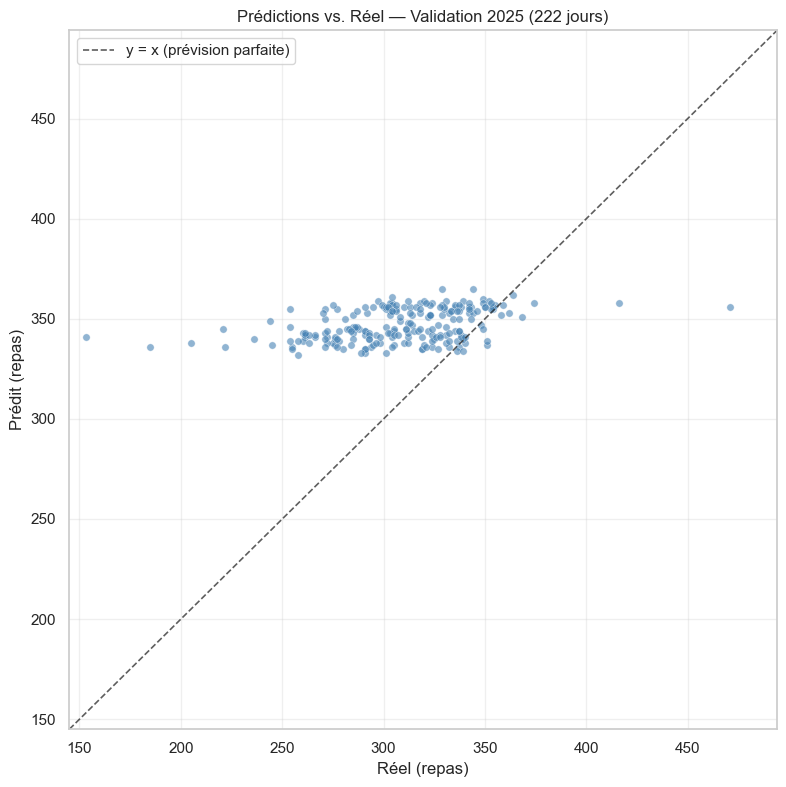

=== Validation 2025 (pipeline en aveugle) — 222 jours ===
  MAE   : 41.36 repas
  RMSE  : 51.15 repas
  Biais : +38.97 repas (réel 307.9 vs prédit 346.9)


In [37]:
# --- Validation 2025 : features en aveugle + cascade déployé ---
import sys
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from api.forecast import _predict_ratio_from_features, _algerian_dow
from src.forecasting.daily_features import generate_features

# 1. Préparer les menus réels 2025
menus_2025 = pd.read_csv(ROOT / 'data' / 'raw' / 'data_2025_.csv')
menus_2025 = menus_2025.rename(columns={'entree': 'entrees'})
menus_2025['date'] = pd.to_datetime(menus_2025['date'])
real_2025 = menus_2025[['date', 'cantine_presence']].copy()
pm_2025 = menus_2025[['date', 'entrees', 'plat_principal_1', 'plat_principal_2']].copy()

# 2. Générer les features en aveugle (pas de vraie météo historique → climatologie)
target_dates = real_2025['date'].sort_values()
feat_2025 = generate_features(
    target_dates=target_dates,
    planned_menus=pm_2025,
    out_path=ROOT / 'data' / 'processed' / 'features_2025_temp.csv',
)
feat_2025['Date'] = pd.to_datetime(feat_2025['Date'])

# 3. Cascade déployé (ratio × office_pred, DOW offset, shrinkage, clip)
offsets   = deploy.get('offsets', {})
lam       = deploy.get('lam_opt', 0.726)
dow_means = deploy.get('dow_mean_actual', {})
clip_lo   = deploy.get('clip_lo', 230.0)
clip_hi   = deploy.get('clip_hi', 520.0)

pred_list = []
for _, row in feat_2025.iterrows():
    ratio = _predict_ratio_from_features(deploy, row)
    op    = float(row.get('office_present_pred', row.get('office_present', 0)))
    raw   = ratio * op
    dow   = _algerian_dow(row['Date'])
    if dow in offsets:
        raw += offsets[dow]
    if dow in dow_means:
        raw = lam * raw + (1 - lam) * dow_means[dow]
    pred_list.append(int(round(float(np.clip(raw, clip_lo, clip_hi)))))

test_2025 = real_2025.rename(columns={'date': 'Date', 'cantine_presence': 'real'}).copy()
test_2025['pred'] = pred_list[:len(test_2025)]

# --- Figure 1 : nuage prédit vs réel ---
err_25 = test_2025['pred'] - test_2025['real']
lim_lo = int(test_2025[['real','pred']].min().min() * 0.95)
lim_hi = int(test_2025[['real','pred']].max().max() * 1.05)

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(test_2025['real'], test_2025['pred'], s=28, color='steelblue', alpha=0.6, edgecolor='white', lw=0.4)
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], 'k--', lw=1.2, alpha=0.7, label='y = x (prévision parfaite)')
ax.set_xlim(lim_lo, lim_hi)
ax.set_ylim(lim_lo, lim_hi)
ax.set_xlabel('Réel (repas)')
ax.set_ylabel('Prédit (repas)')
ax.set_title('Prédictions vs. Réel — Validation 2025 (%d jours)' % len(test_2025))
ax.legend(frameon=True)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(ROOT / 'data' / 'processed' / 'synth_pred_vs_real_2025.png', dpi=120, bbox_inches='tight')
plt.show()

# --- Métriques ---
mae_25  = float(np.mean(np.abs(err_25)))
rmse_25 = float(np.sqrt(np.mean(err_25 ** 2)))
print('=== Validation 2025 (pipeline en aveugle) — %d jours ===' % len(test_2025))
print('  MAE   : %.2f repas' % mae_25)
print('  RMSE  : %.2f repas' % rmse_25)
print('  Biais : %+.2f repas (réel %.1f vs prédit %.1f)' % (
    float(err_25.mean()), float(test_2025['real'].mean()), float(test_2025['pred'].mean())))


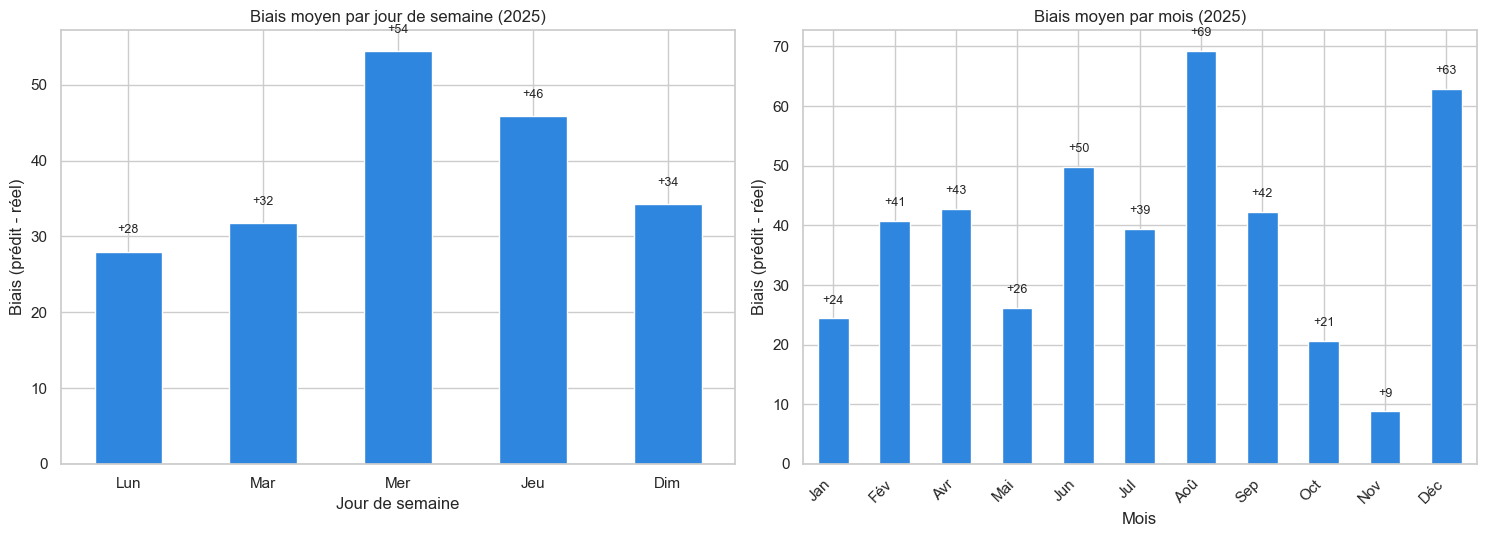

=== Biais moyen par jour de semaine (2025) ===
      n      biais        mae
dow                          
Lun  45  28.000000  34.533333
Mar  44  31.727273  34.590909
Mer  46  54.456522  54.456522
Jeu  44  45.863636  47.500000
Dim  43  34.232558  35.162791

=== Biais moyen par mois (2025) ===
        n      biais        mae
month                          
Jan    20  24.400000  28.000000
Fév    19  40.684211  40.894737
Avr    20  42.750000  42.950000
Mai    20  26.200000  37.700000
Jun    21  49.761905  49.857143
Jul    18  39.388889  39.388889
Aoû    21  69.238095  69.238095
Sep    17  42.235294  43.882353
Oct    22  20.681818  21.227273
Nov    21   8.809524  17.380952
Déc    23  62.826087  62.826087


In [38]:
# --- Figure 2 : erreurs moyennes par jour de semaine et par mois ---
test_2025['dow']      = test_2025['Date'].dt.dayofweek
test_2025['month']    = test_2025['Date'].dt.month
test_2025['abs_err']  = err_25.abs()
test_2025['err']      = err_25

dow_map = {0: 'Lun', 1: 'Mar', 2: 'Mer', 3: 'Jeu', 4: 'Ven', 5: 'Sam', 6: 'Dim'}
month_map = {i: m for i, m in enumerate(
    ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc'], 1)}

dow_err = test_2025.groupby('dow').agg(
    n=('err', 'count'),
    biais=('err', 'mean'),
    mae=('abs_err', 'mean'),
).sort_index()
dow_err.index = dow_err.index.map(lambda x: dow_map.get(x, str(x)))

month_err = test_2025.groupby('month').agg(
    n=('err', 'count'),
    biais=('err', 'mean'),
    mae=('abs_err', 'mean'),
).sort_index()
month_err.index = month_err.index.map(lambda x: month_map.get(x, str(x)))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# biais par DOW
colors_dow = ['#2e86de' if v >= 0 else '#e74c3c' for v in dow_err['biais']]
dow_err['biais'].plot(kind='bar', ax=axes[0], color=colors_dow, edgecolor='white')
axes[0].axhline(y=0, color='black', lw=0.8, alpha=0.5)
axes[0].set_title('Biais moyen par jour de semaine (2025)')
axes[0].set_ylabel('Biais (prédit - réel)')
axes[0].set_xlabel('Jour de semaine')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=0, ha='center')
for idx, v in enumerate(dow_err['biais']):
    axes[0].text(idx, v + (2 if v >= 0 else -4), '%+.0f' % v,
                 ha='center', va='bottom' if v >= 0 else 'top', fontsize=9)

# biais par mois
colors_m = ['#2e86de' if v >= 0 else '#e74c3c' for v in month_err['biais']]
month_err['biais'].plot(kind='bar', ax=axes[1], color=colors_m, edgecolor='white')
axes[1].axhline(y=0, color='black', lw=0.8, alpha=0.5)
axes[1].set_title('Biais moyen par mois (2025)')
axes[1].set_ylabel('Biais (prédit - réel)')
axes[1].set_xlabel('Mois')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')
for idx, v in enumerate(month_err['biais']):
    axes[1].text(idx, v + (2 if v >= 0 else -4), '%+.0f' % v,
                 ha='center', va='bottom' if v >= 0 else 'top', fontsize=9)

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'processed' / 'synth_errors_by_dow_month_2025.png', dpi=120, bbox_inches='tight')
plt.show()

print('=== Biais moyen par jour de semaine (2025) ===')
print((dow_err[['n','biais','mae']].to_string()))
print('\n=== Biais moyen par mois (2025) ===')
print((month_err[['n','biais','mae']].to_string()))


In [39]:
print("""=== Pourquoi l'approche cascade (B) a été retenue ===

1. Séparation des responsabilités :
   - Sous-modèle : prédit la PRÉSENCE AU BUREAU (facteur externe)
   - Modèle principal : prédit le RATIO cantine/bureau (comportement interne)

2. Meilleure interprétabilité :
   - Le gestionnaire comprend : "507 au bureau × ratio 0.60 → 305 repas"
   - Vs modèle direct : "305 repas" (boîte noire)

3. Flexibilité opérationnelle :
   - Le gestionnaire peut ajuster la présence manuellement dans l'UI
   - Le ratio est recalculé automatiquement

4. Performance supérieure (OOF AsymCost 23.85 vs 28.65)

5. Facilité de maintenance : modèles entraînés et déployés séparément""")

=== Pourquoi l'approche cascade (B) a été retenue ===

1. Séparation des responsabilités :
   - Sous-modèle : prédit la PRÉSENCE AU BUREAU (facteur externe)
   - Modèle principal : prédit le RATIO cantine/bureau (comportement interne)

2. Meilleure interprétabilité :
   - Le gestionnaire comprend : "507 au bureau × ratio 0.60 → 305 repas"
   - Vs modèle direct : "305 repas" (boîte noire)

3. Flexibilité opérationnelle :
   - Le gestionnaire peut ajuster la présence manuellement dans l'UI
   - Le ratio est recalculé automatiquement

4. Performance supérieure (OOF AsymCost 23.85 vs 28.65)

5. Facilité de maintenance : modèles entraînés et déployés séparément


---
# 8. CONCLUSION GÉNÉRALE

In [40]:
asym_cost_abs = oof_metrics['AsymCost']
asym_cost_pct = (asym_cost_abs / target_mean) * 100

print("=" * 60)
print("  RÉSULTATS FINAUX — MODÈLE CASCADE RIE BNP PARIBAS")
print("=" * 60)
print(f"")
print(f"  Asym. Cost (OOF)     : {asym_cost_abs:.2f} repas")
print(f"  Asym. Cost (% moy.)  : {asym_cost_pct:.1f}%")
print(f"  MAE (OOF)            : {oof_metrics['MAE']:.2f} repas")
print(f"  RMSE (OOF)           : {oof_metrics['RMSE']:.2f} repas")
print(f"")
print(f"  Test Asym. Cost      : {test_metrics['AsymCost']:.2f} repas")
print(f"  Test MAE             : {test_metrics['MAE']:.2f} repas")
print(f"  Test RMSE            : {test_metrics['RMSE']:.2f} repas")
print(f"")
print(f"  Benchmark :")
print(f"    < 5%  → Excellent")
print(f"    5-10% → Bon / Production-ready")
print(f"    > 15% → Insuffisant")
print(f"")
print(f"  → Le modèle est {'EXCELLENT' if asym_cost_pct < 5 else 'BON / Production-ready' if asym_cost_pct < 10 else 'INSUFFISANT'} ({asym_cost_pct:.1f}%)")
print("=" * 60)


  RÉSULTATS FINAUX — MODÈLE CASCADE RIE BNP PARIBAS

  Asym. Cost (OOF)     : 24.05 repas
  Asym. Cost (% moy.)  : 7.3%
  MAE (OOF)            : 16.47 repas
  RMSE (OOF)           : 21.85 repas

  Test Asym. Cost      : 20.23 repas
  Test MAE             : 18.91 repas
  Test RMSE            : 26.21 repas

  Benchmark :
    < 5%  → Excellent
    5-10% → Bon / Production-ready
    > 15% → Insuffisant

  → Le modèle est BON / Production-ready (7.3%)


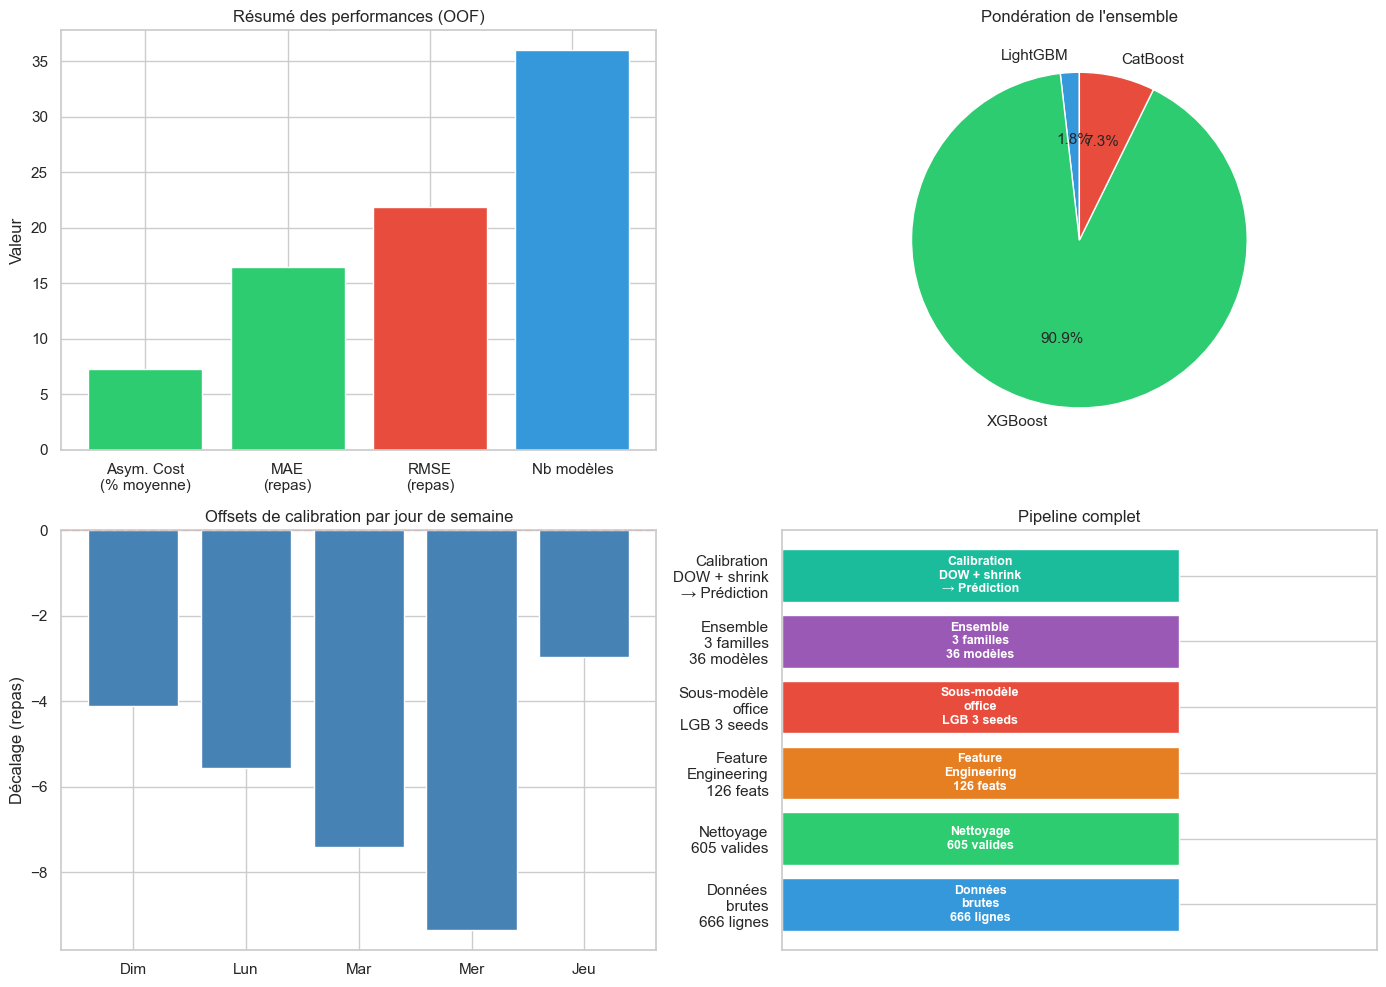

In [41]:
# Résumé visuel final
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Métriques clés
metrics_names = ['Asym. Cost\n(% moyenne)', 'MAE\n(repas)', 'RMSE\n(repas)', 'Nb modèles']
metrics_vals = [asym_cost_pct, oof_metrics['MAE'], oof_metrics['RMSE'], 36]
colors_bar = ['#2ecc71' if v < 20 else '#e74c3c' for v in [asym_cost_pct, oof_metrics['MAE'], oof_metrics['RMSE']]]
colors_bar.append('#3498db')
axes[0, 0].bar(metrics_names, metrics_vals, color=colors_bar, edgecolor='white')
axes[0, 0].set_title('Résumé des performances (OOF)')
axes[0, 0].set_ylabel('Valeur')

# 2. Blend weights
blend_names = ['LightGBM', 'XGBoost', 'CatBoost']
blend_vals = deploy['best_blend_w'] * 100
axes[0, 1].pie(blend_vals, labels=blend_names, autopct='%1.1f%%',
               colors=['#3498db', '#2ecc71', '#e74c3c'], startangle=90)
axes[0, 1].set_title('Pondération de l\'ensemble')

# 3. Calibration offsets
dow_labels_short = ['Dim', 'Lun', 'Mar', 'Mer', 'Jeu']
dow_keys = [6, 0, 1, 2, 3]
offset_vals = [deploy['offsets'].get(k, 0) for k in dow_keys]
axes[1, 0].bar(dow_labels_short, offset_vals, color='steelblue', edgecolor='white')
axes[1, 0].set_title('Offsets de calibration par jour de semaine')
axes[1, 0].set_ylabel('Décalage (repas)')
axes[1, 0].axhline(y=0, color='red', linestyle='--', alpha=0.5)

# 4. Pipeline
pipeline_steps = ['Données\nbrutes\n666 lignes', 'Nettoyage\n605 valides', 'Feature\nEngineering\n126 feats',
                  'Sous-modèle\noffice\nLGB 3 seeds', 'Ensemble\n3 familles\n36 modèles', 'Calibration\nDOW + shrink\n→ Prédiction']
axes[1, 1].barh(pipeline_steps, [1]*6, color=['#3498db','#2ecc71','#e67e22','#e74c3c','#9b59b6','#1abc9c'], edgecolor='white')
axes[1, 1].set_title('Pipeline complet')
axes[1, 1].set_xlim(0, 1.5)
axes[1, 1].set_xticks([])
for i, step in enumerate(pipeline_steps):
    axes[1, 1].text(0.5, i, step, ha='center', va='center', fontweight='bold', color='white', fontsize=9)

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'processed' / 'synth_final_summary.png', dpi=120, bbox_inches='tight')
plt.show()

In [42]:
print("""=== Limites connues ===

1. Données d'entraînement limitées (372 jours valides, mai 2022 — déc 2023)
   → Les données 2024 ne servent qu'en test, pas en entraînement

2. Sous-modèle office_presence : features uniquement calendaires + météo + lags
   → Ne tient pas compte des événements internes (séminaires, congés collectifs)

3. Calibration DOW statique (moyennes historiques)
   → Ne s'adapte pas aux changements de comportement post-COVID

4. Pas de prise en compte des événements spéciaux
   → Ramadan, ponts, événements d'entreprise non modélisés directement

5. 126 features avec risque de sur-apprentissage sur petit échantillon
   → Atténué par la validation croisée temporelle et le shrinkage""")

print("""=== Prochaines étapes recommandées ===

1. Réentraîner avec les données 2024 une fois disponibles
2. Intégrer les données d'événements internes (calendrier RH)
3. Optimiser le sous-modèle avec données de badges d'accès
4. Mettre en place un monitoring de drift en production
5. Ajouter un module de recommandation de menu (waste history)
6. Tester un modèle end-to-end pour comparaison avec cascade""")

=== Limites connues ===

1. Données d'entraînement limitées (372 jours valides, mai 2022 — déc 2023)
   → Les données 2024 ne servent qu'en test, pas en entraînement

2. Sous-modèle office_presence : features uniquement calendaires + météo + lags
   → Ne tient pas compte des événements internes (séminaires, congés collectifs)

3. Calibration DOW statique (moyennes historiques)
   → Ne s'adapte pas aux changements de comportement post-COVID

4. Pas de prise en compte des événements spéciaux
   → Ramadan, ponts, événements d'entreprise non modélisés directement

5. 126 features avec risque de sur-apprentissage sur petit échantillon
   → Atténué par la validation croisée temporelle et le shrinkage
=== Prochaines étapes recommandées ===

1. Réentraîner avec les données 2024 une fois disponibles
2. Intégrer les données d'événements internes (calendrier RH)
3. Optimiser le sous-modèle avec données de badges d'accès
4. Mettre en place un monitoring de drift en production
5. Ajouter un module 

In [43]:
# Sauvegarder les artefacts de synthèse
save_dir = ROOT / 'data' / 'processed'

desc_num.to_csv(save_dir / 'synth_stats_numeriques.csv', index=False)
corr.to_csv(save_dir / 'synth_matrice_correlation.csv')

final_metrics = {
    'source_file': 'data/raw/real.csv',
    'n_raw_rows': int(n_total),
    'n_valid_rows': int(n_valid),
    'n_features': len(feat_cols),
    'n_models': len(deploy['lgb_models']) + len(deploy['xgb_models']) + len(cb_models_raw),
    'asym_cost_oof': float(asym_cost_abs),
    'asym_cost_pct': float(asym_cost_pct),
    'mae_oof': float(oof_metrics['MAE']),
    'rmse_oof': float(oof_metrics['RMSE']),
    'test_asym_cost': float(test_metrics['AsymCost']),
    'test_mae': float(test_metrics['MAE']),
    'test_rmse': float(test_metrics['RMSE']),
    'blend_weights': {k: float(v) for k, v in zip(['lgb', 'xgb', 'catboost'], deploy['best_blend_w'])},
    'lambda_shrinkage': float(deploy['lam_opt']),
    'target_mean': target_mean,
    'benchmark': 'EXCELLENT' if asym_cost_pct < 5 else 'BON' if asym_cost_pct < 10 else 'INSUFFISANT',
}
with open(save_dir / 'synth_final_metrics.json', 'w') as f:
    json.dump(final_metrics, f, indent=2)

print("Artefacts sauvegardés dans data/processed/synth_*")
print("\n=== Synthèse terminée ===")


Artefacts sauvegardés dans data/processed/synth_*

=== Synthèse terminée ===
